In [1]:
import cosinorage as csa

from utils import recompute_wear_periods, plot_pig_wear_timeseries, save_modified_timeseries, compare_cohorts_daily_signal, load_cohort_data

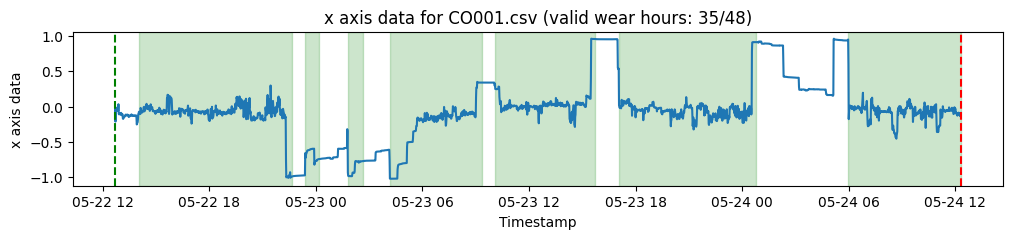

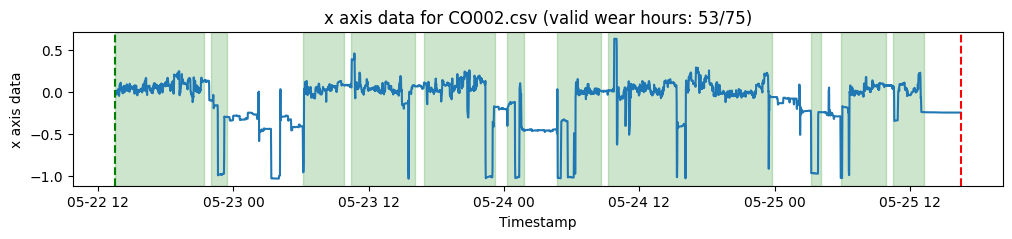

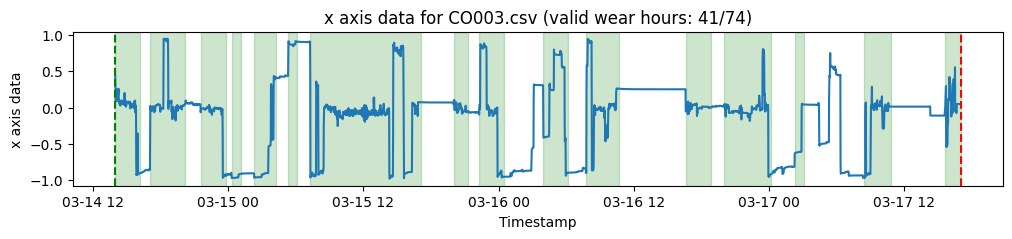

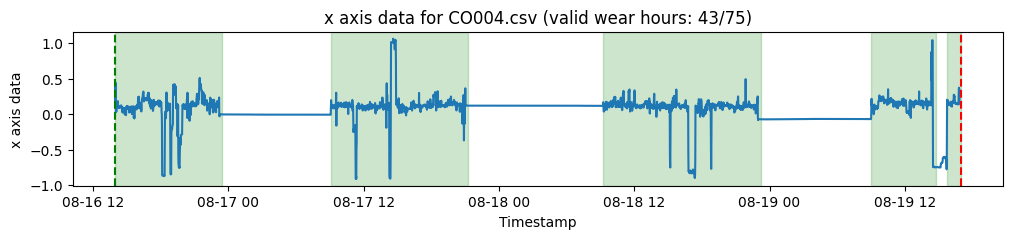

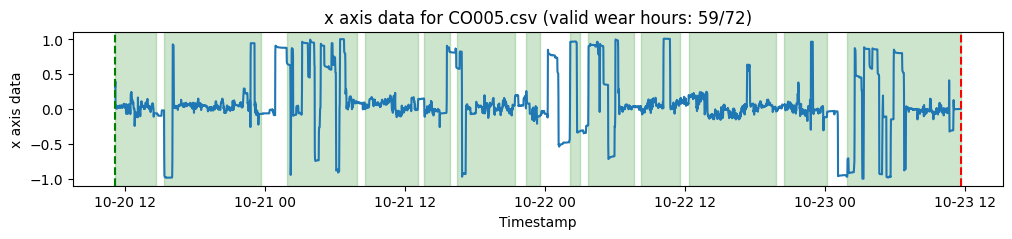

In [2]:
recompute_wear_periods()
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level", limit=5, axis='x')

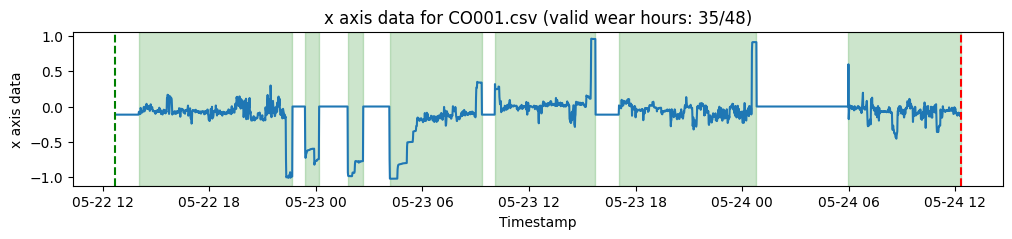

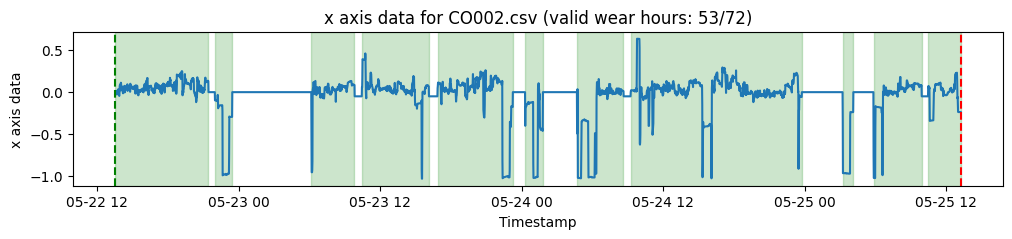

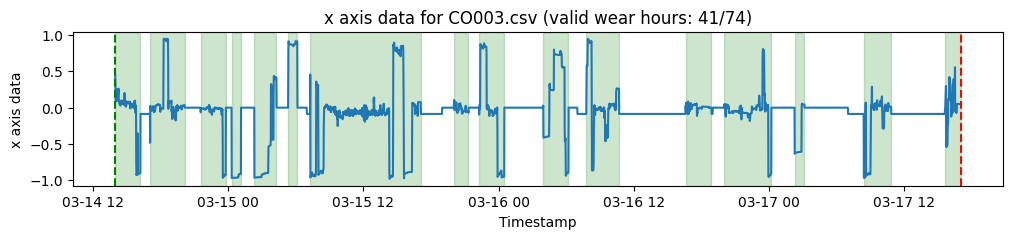

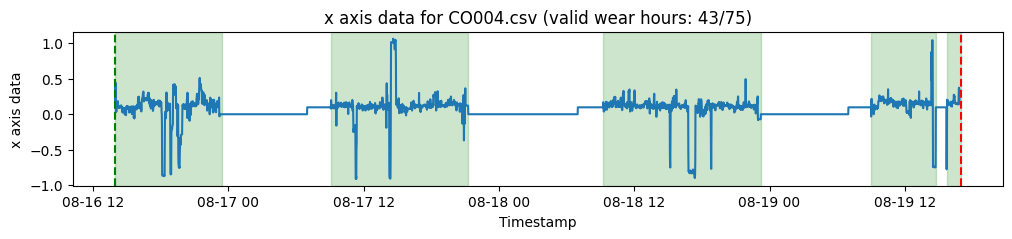

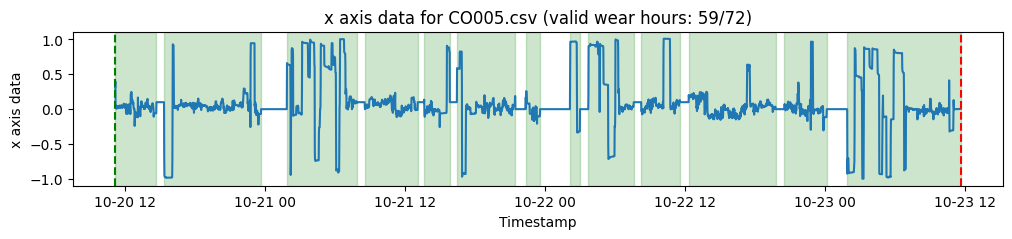

In [3]:
save_modified_timeseries("wear_periods_recomputed.csv", "minute_level", output_dir="minute_level_modified")
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level_modified", limit=5, axis='x')

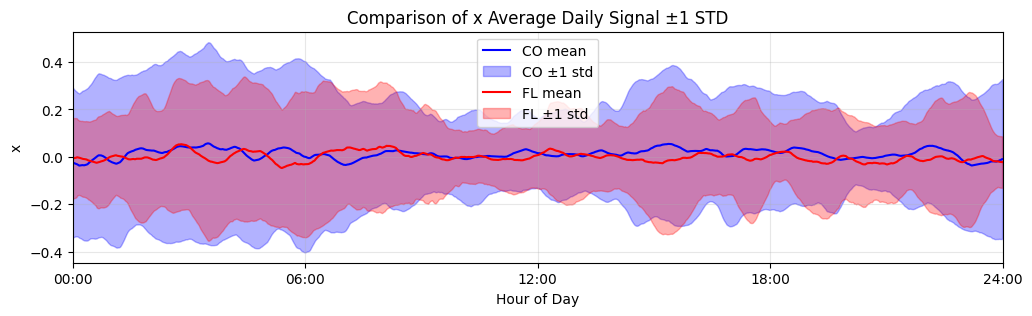

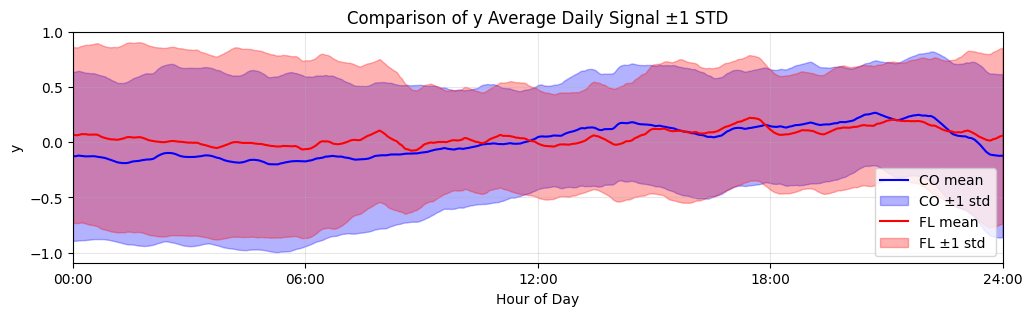

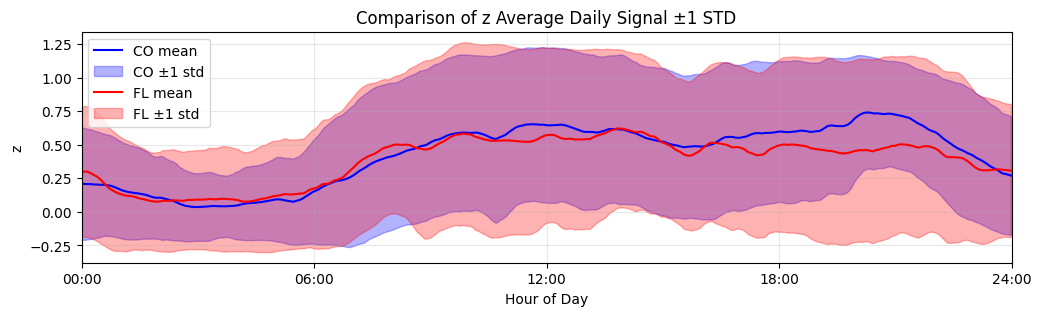

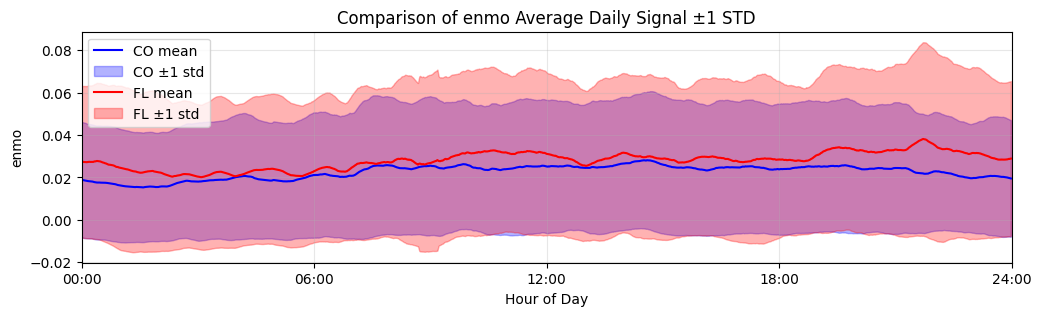

In [4]:
compare_cohorts_daily_signal(co_pattern="CO*.csv", fl_pattern="FL*.csv", folder="minute_level_modified", columns=['x','y','z','enmo'], window=30)

In [5]:
co_handlers, co_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="CO*.csv", preprocess_args=None)
fl_handlers, fl_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="FL*.csv", preprocess_args=None)

Error processing CO024.csv: Less than 1 day found
Error processing FL009.csv: Less than 1 day found


In [6]:
features_args = {}

co_features = csa.features.BulkWearableFeatures(
    handlers=co_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=co_cosinor_age_inputs
    )

co_features .get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,33,21.059797,15.250790,0.890176,52.657464,18.520061,7.454066,30.354279,22.900213,0.890176,0.558243
1,cosinor_amplitude,33,13.864434,10.369743,0.637734,39.656014,12.570529,4.674387,16.643843,11.969457,0.637734,0.826901
2,cosinor_acrophase,33,-3.049404,1.702956,-5.888238,-0.178364,-3.561921,-4.219508,-1.339595,2.879914,-5.888238,0.115191
3,cosinor_acrophase_time,33,698.872025,390.288840,40.877990,1349.484643,816.332203,307.012450,967.040103,660.027653,40.877990,-0.115191
4,nonparam_IS,33,0.646332,0.259571,0.209507,1.000000,0.696560,0.392161,0.865070,0.472909,1.000000,-0.135288
5,nonparam_IV,33,0.716838,0.405549,0.147681,1.764827,0.638272,0.411339,0.974208,0.562869,0.147681,0.909657
6,nonparam_M10,33,33.775668,22.192362,1.589911,78.685787,34.013045,17.110427,45.722024,28.611598,1.589911,0.368716
7,nonparam_L5,33,3.451006,5.460756,0.000000,20.140735,0.049367,0.000000,5.371754,5.371754,0.000000,1.718909
8,nonparam_RA,33,0.882419,0.158488,0.508946,1.000000,0.995329,0.754521,1.000000,0.245479,1.000000,-1.065212
9,physical_activity_sedentary,33,744.712121,354.152104,116.500000,1380.500000,750.000000,479.500000,1023.000000,543.500000,116.500000,0.093936


In [7]:
fl_features = csa.features.BulkWearableFeatures(
    handlers=fl_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=fl_cosinor_age_inputs
    )

fl_features .get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,19,29.392716,21.039928,0.271353,65.463433,29.294563,11.466336,50.220328,38.753992,0.271353,0.134803
1,cosinor_amplitude,19,20.277736,19.106571,0.481818,79.163323,14.291483,4.819602,28.160185,23.340583,0.481818,1.618257
2,cosinor_acrophase,19,-3.560720,1.866225,-6.264906,-0.487385,-4.183278,-4.754948,-2.023210,2.731738,-6.264906,0.636943
3,cosinor_acrophase_time,19,816.056853,427.707160,111.700336,1435.810800,958.736686,463.685582,1089.753779,626.068197,111.700336,-0.636943
4,nonparam_IS,19,0.671587,0.251584,0.263043,1.000000,0.693034,0.420373,0.897189,0.476816,1.000000,-0.135620
5,nonparam_IV,19,0.699217,0.413926,0.143992,1.615993,0.680341,0.312672,1.021737,0.709065,0.143992,0.458320
6,nonparam_M10,19,43.264005,30.105911,0.651246,89.119899,34.536975,20.430809,76.227949,55.797140,0.651246,0.125579
7,nonparam_L5,19,6.730433,10.151254,0.000000,39.375710,1.903126,0.000000,9.466543,9.466543,0.000000,2.058742
8,nonparam_RA,19,0.802495,0.239201,0.214535,1.000000,0.949827,0.613143,1.000000,0.386857,1.000000,-1.036435
9,physical_activity_sedentary,19,650.552632,381.963552,133.000000,1382.000000,517.000000,356.250000,869.500000,513.250000,133.000000,0.764174


In [8]:
co_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.757494,-0.162197,0.162197,0.228131,-0.419069,0.969766,0.616202,-0.494710,-0.842175,...,0.010211,0.842887,-0.791687,0.252514,-0.791687,-0.216520,0.214390,0.230095,-0.552965,-0.728511
cosinor_amplitude,0.757494,1.000000,0.108559,-0.108559,0.334361,-0.587797,0.857948,0.150730,0.008880,-0.460143,...,0.067896,0.460215,-0.399290,0.000738,-0.399289,-0.153190,0.144151,0.118308,-0.731118,-0.782281
cosinor_acrophase,-0.162197,0.108559,1.000000,-1.000000,0.192229,-0.267365,-0.112123,-0.140887,0.041662,0.139545,...,0.305478,-0.141748,0.304616,-0.118986,0.304616,0.336180,-0.037046,0.406283,-0.115172,-0.105727
cosinor_acrophase_time,0.162197,-0.108559,-1.000000,1.000000,-0.192229,0.267365,0.112123,0.140887,-0.041662,-0.139545,...,-0.305478,0.141748,-0.304616,0.118986,-0.304616,-0.336180,0.037046,-0.406283,0.115172,0.105727
nonparam_IS,0.228131,0.334361,0.192229,-0.192229,1.000000,0.012167,0.176392,0.021814,0.113645,-0.169786,...,-0.327614,0.171653,-0.183335,-0.091134,-0.183332,-0.422532,-0.071744,0.684706,-0.032180,-0.148575
nonparam_IV,-0.419069,-0.587797,-0.267365,0.267365,0.012167,1.000000,-0.515995,-0.084040,0.036282,0.446220,...,-0.218899,-0.445327,0.389746,-0.059836,0.389744,0.033137,-0.404848,0.037644,0.649639,0.704919
nonparam_M10,0.969766,0.857948,-0.112123,0.112123,0.176392,-0.515995,1.000000,0.499018,-0.361856,-0.761698,...,0.040926,0.762192,-0.711088,0.220128,-0.711088,-0.183794,0.224406,0.135345,-0.676026,-0.813982
nonparam_L5,0.616202,0.150730,-0.140887,0.140887,0.021814,-0.084040,0.499018,1.000000,-0.926260,-0.742956,...,0.048842,0.743273,-0.646075,0.332549,-0.646075,-0.120591,0.056541,0.277861,-0.078614,-0.303522
nonparam_RA,-0.494710,0.008880,0.041662,-0.041662,0.113645,0.036282,-0.361856,-0.926260,1.000000,0.746743,...,-0.229063,-0.745922,0.642144,-0.462502,0.642145,-0.084483,-0.048215,-0.260314,-0.026052,0.231397
physical_activity_sedentary,-0.842175,-0.460143,0.139545,-0.139545,-0.169786,0.446220,-0.761698,-0.742956,0.746743,1.000000,...,-0.144503,-0.999984,0.953806,-0.481552,0.953806,0.132375,-0.260962,-0.300396,0.387910,0.672416


In [9]:
fl_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.747191,0.152344,-0.152344,0.389813,-0.021886,0.980480,0.689340,-0.457230,-0.710760,...,-0.132494,0.716038,-0.757774,0.419654,-0.757775,-0.225270,-0.196610,0.563577,-0.744277,-0.934070
cosinor_amplitude,0.747191,1.000000,0.117576,-0.117576,0.547636,-0.436262,0.854882,0.093740,0.092635,-0.461059,...,0.112957,0.461410,-0.537648,0.199430,-0.537649,-0.154758,-0.008474,0.317128,-0.532455,-0.759790
cosinor_acrophase,0.152344,0.117576,1.000000,-1.000000,-0.090667,-0.404175,0.186773,0.045596,-0.286501,-0.450350,...,0.252864,0.448098,-0.438319,0.557760,-0.438316,0.493327,0.000797,0.187681,-0.072945,-0.356496
cosinor_acrophase_time,-0.152344,-0.117576,-1.000000,1.000000,0.090667,0.404175,-0.186773,-0.045596,0.286501,0.450350,...,-0.252864,-0.448098,0.438319,-0.557760,0.438316,-0.493327,-0.000797,-0.187681,0.072945,0.356496
nonparam_IS,0.389813,0.547636,-0.090667,0.090667,1.000000,-0.007450,0.465981,0.087038,0.084868,-0.312015,...,0.496325,0.305395,-0.152277,0.482067,-0.152275,-0.009684,-0.379660,0.400346,-0.504018,-0.373453
nonparam_IV,-0.021886,-0.436262,-0.404175,0.404175,-0.007450,1.000000,-0.132941,0.406422,-0.243586,0.245516,...,-0.460549,-0.239211,0.220498,-0.173879,0.220497,-0.370826,0.121881,-0.087686,0.043949,0.179619
nonparam_M10,0.980480,0.854882,0.186773,-0.186773,0.465981,-0.132941,1.000000,0.564816,-0.333923,-0.691287,...,-0.062727,0.695378,-0.739394,0.402672,-0.739395,-0.205816,-0.149495,0.526627,-0.721220,-0.938050
nonparam_L5,0.689340,0.093740,0.045596,-0.045596,0.087038,0.406422,0.564816,1.000000,-0.844079,-0.598070,...,-0.245300,0.604525,-0.554864,0.488333,-0.554864,-0.057389,-0.330986,0.554346,-0.508638,-0.553663
nonparam_RA,-0.457230,0.092635,-0.286501,0.286501,0.084868,-0.243586,-0.333923,-0.844079,1.000000,0.689788,...,0.082399,-0.693936,0.613244,-0.530819,0.613242,-0.209686,0.238435,-0.630301,0.372955,0.358818
physical_activity_sedentary,-0.710760,-0.461059,-0.450350,0.450350,-0.312015,0.245516,-0.691287,-0.598070,0.689788,1.000000,...,-0.272390,-0.999880,0.898910,-0.609092,0.898910,-0.088127,0.242359,-0.780813,0.656968,0.726629
